# 01 · Research Methods, Hands-On

Companion notebook to **Note 01 · Why Research? and the Research Path** (Introduction to Research).

The note explains *why* a research claim needs evidence; this notebook shows *how* that evidence is produced for a typical data-science claim such as "Model B is better than Model A".

| Part | Topic |
|---|---|
| 1 | Comparing two ML models over random seeds (Welch and paired t-tests, effect size) |
| 2 | The same effect, different sample sizes: how p-values shrink with n |
| 3 | Type I error rate simulation (and the multiple-comparisons trap) |
| 4 | Power analysis: analytic formula vs simulation |
| 5 | Bootstrap confidence interval for test accuracy |
| 6 | Checking the note's hand-worked paired vs Welch example |
| 7 | Sample size for a target margin of error (with finite-population correction) |
| 8 | Two models on the same test set: two-proportion z-test vs McNemar's test |
| 9 | Confounding and Simpson's paradox: crude vs stratified comparison |
| 10 | p-hacking by optional stopping ("peeking") inflates the Type I error |
| 11 | How many published "discoveries" are true? (positive predictive value) |

Only numpy, scipy, pandas, matplotlib and scikit-learn are used; the dataset (`load_breast_cancer`) ships with scikit-learn, so nothing is downloaded.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.dpi'] = 110

## Part 1 · Is Model B really better than Model A?

**Research question:** on the Breast Cancer Wisconsin data, does a scaled logistic regression classify more accurately than a depth-limited decision tree?

- **Independent variable:** the model (LR vs tree).
- **Dependent variable:** test accuracy.
- **Controlled variables:** same data, same split ratio (75/25), same seed list.
- **Source of randomness:** the train/test split, re-drawn for each of 15 seeds.

Because both models are evaluated on *the same split for each seed*, the natural test is the **paired t-test** on the per-seed differences. The Welch (unpaired) test is shown for comparison.

In [2]:
X, y = load_breast_cancer(return_X_y=True)
seeds = range(15)
rows = []
for s in seeds:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=s, stratify=y)
    lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(Xtr, ytr)
    dt = DecisionTreeClassifier(max_depth=3, random_state=s).fit(Xtr, ytr)
    rows.append({'seed': s, 'acc_LR': lr.score(Xte, yte), 'acc_tree': dt.score(Xte, yte)})
res = pd.DataFrame(rows)
res['diff'] = res.acc_LR - res.acc_tree
print(res.round(4).to_string(index=False))
print()
print(res[['acc_LR', 'acc_tree', 'diff']].agg(['mean', 'std']).round(4))

 seed  acc_LR  acc_tree   diff
    0   0.958    0.9161 0.0420
    1   0.965    0.9441 0.0210
    2   0.972    0.9231 0.0490
    3   0.986    0.9231 0.0629
    4   0.972    0.9371 0.0350
    5   0.979    0.9441 0.0350
    6   0.993    0.9510 0.0420
    7   0.979    0.9301 0.0490
    8   0.972    0.9161 0.0559
    9   0.979    0.9231 0.0559
   10   0.972    0.9161 0.0559
   11   0.958    0.9301 0.0280
   12   0.986    0.8811 0.1049
   13   0.972    0.9301 0.0420
   14   0.986    0.9510 0.0350

      acc_LR  acc_tree    diff
mean  0.9753    0.9277  0.0476
std   0.0102    0.0177  0.0196


In [3]:
welch = stats.ttest_ind(res.acc_LR, res.acc_tree, equal_var=False)
paired = stats.ttest_rel(res.acc_LR, res.acc_tree)
d_cohen = (res.acc_LR.mean() - res.acc_tree.mean()) / np.sqrt((res.acc_LR.var(ddof=1) + res.acc_tree.var(ddof=1)) / 2)
d_z = res['diff'].mean() / res['diff'].std(ddof=1)          # effect size for paired designs
n = len(res)
se = res['diff'].std(ddof=1) / np.sqrt(n)
tcrit = stats.t.ppf(0.975, n - 1)
ci = (res['diff'].mean() - tcrit * se, res['diff'].mean() + tcrit * se)
print(f"Welch  t = {welch.statistic:.3f}, p = {welch.pvalue:.2e}")
print(f"Paired t = {paired.statistic:.3f}, p = {paired.pvalue:.2e}")
print(f"Cohen's d (pooled) = {d_cohen:.2f};  d_z (paired) = {d_z:.2f}")
print(f"95% CI for mean accuracy gain: [{ci[0]:.4f}, {ci[1]:.4f}]")

Welch  t = 9.031, p = 6.39e-09
Paired t = 9.379, p = 2.06e-07
Cohen's d (pooled) = 3.30;  d_z (paired) = 2.42
95% CI for mean accuracy gain: [0.0367, 0.0584]


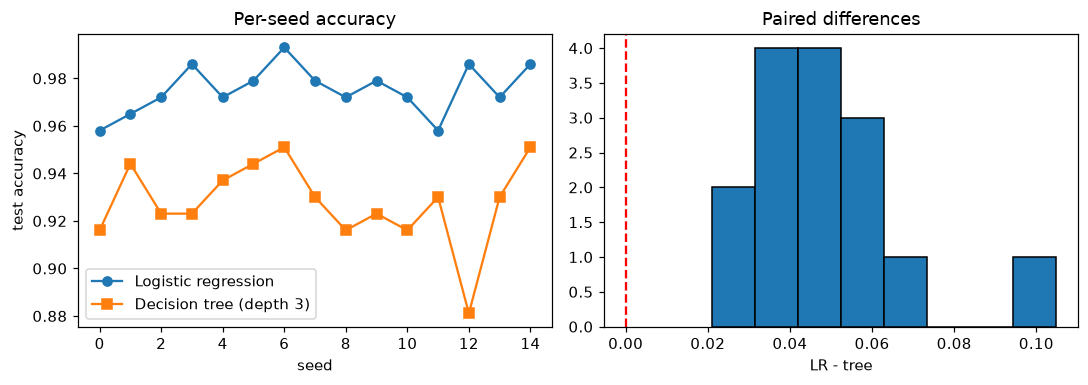

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(res.seed, res.acc_LR, 'o-', label='Logistic regression')
ax[0].plot(res.seed, res.acc_tree, 's-', label='Decision tree (depth 3)')
ax[0].set_xlabel('seed'); ax[0].set_ylabel('test accuracy'); ax[0].legend(); ax[0].set_title('Per-seed accuracy')
ax[1].hist(res['diff'], bins=8, edgecolor='k'); ax[1].axvline(0, color='r', ls='--')
ax[1].set_xlabel('LR - tree'); ax[1].set_title('Paired differences')
plt.tight_layout(); plt.show()

**Reading the result.** Logistic regression wins on all 15 seeds, by about 4.8 accuracy points on average, and both tests reject H₀ decisively. The paired test works on the per-seed differences, which removes the split-to-split noise the two models share (seeds 0 and 11, for example, are below average for both models); its t is slightly larger, though with 14 instead of about 22 degrees of freedom its p-value is not smaller here. When the shared noise is large relative to the effect, pairing makes a big difference (see the worked example in the note). Report the **mean gain, its 95 % CI and the effect size**, not only the p-value.

> Caveat: train/test splits from the same 569 samples overlap, so the per-seed results are not fully independent and the t-test is somewhat optimistic. Corrected resampled t-tests (Nadeau & Bengio, 2003) address this; for an M.Tech report, at least state the caveat.

## Part 2 · Same effect, different n

A fixed true difference of 1 accuracy point (0.84 vs 0.85, per-run standard deviation 0.01) is tested with 3, 5, 10, 20 and 50 runs per model. For each n the experiment is repeated 2,000 times and the **median p-value** is recorded.

 runs per model  median p  share p<0.05
              3    0.2618        0.1255
              5    0.1409        0.2615
             10    0.0396        0.5485
             20    0.0030        0.8785
             50    0.0000        0.9980


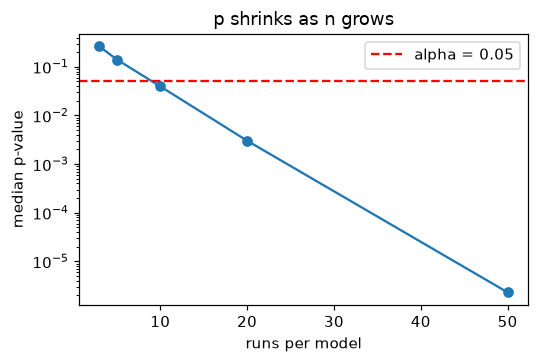

In [5]:
rng = np.random.default_rng(0)
ns = [3, 5, 10, 20, 50]
out = []
for n in ns:
    a = rng.normal(0.84, 0.01, size=(2000, n))
    b = rng.normal(0.85, 0.01, size=(2000, n))
    p = stats.ttest_ind(b, a, axis=1, equal_var=False).pvalue
    out.append({'runs per model': n, 'median p': np.median(p), 'share p<0.05': (p < 0.05).mean()})
tab2 = pd.DataFrame(out); print(tab2.round(4).to_string(index=False))
plt.figure(figsize=(5, 3.4)); plt.semilogy(tab2['runs per model'], tab2['median p'], 'o-')
plt.axhline(0.05, color='r', ls='--', label='alpha = 0.05'); plt.xlabel('runs per model'); plt.ylabel('median p-value'); plt.legend(); plt.title('p shrinks as n grows'); plt.tight_layout(); plt.show()

The **effect size never changed** (Cohen's d = 1 throughout); only n changed. A p-value mixes effect size and sample size, which is why it must be reported together with an effect size and a confidence interval.

## Part 3 · Type I error rate

When H₀ is true (both models have identical mean accuracy), a test at α = 0.05 should wrongly reject about 5 % of the time. The second cell shows what happens when 20 independent comparisons are run and *any* significant one is reported.

Empirical Type I error rate at alpha=0.05: 0.0471


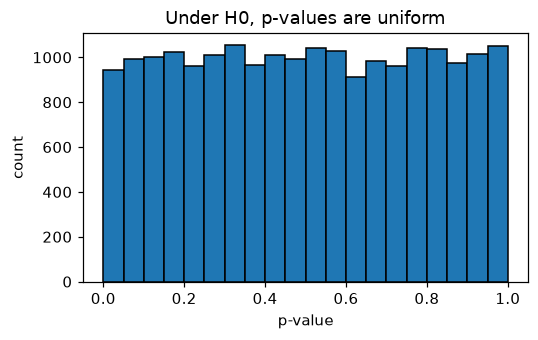

In [6]:
rng = np.random.default_rng(1)
reps, n = 20000, 10
a = rng.normal(0.85, 0.01, size=(reps, n)); b = rng.normal(0.85, 0.01, size=(reps, n))
p = stats.ttest_ind(a, b, axis=1).pvalue
print(f"Empirical Type I error rate at alpha=0.05: {(p < 0.05).mean():.4f}")
plt.figure(figsize=(5, 3.2)); plt.hist(p, bins=20, edgecolor='k'); plt.xlabel('p-value'); plt.ylabel('count'); plt.title('Under H0, p-values are uniform'); plt.tight_layout(); plt.show()

In [7]:
rng = np.random.default_rng(2)
reps, k = 5000, 20
p = stats.ttest_ind(rng.normal(size=(reps, k, 10)), rng.normal(size=(reps, k, 10)), axis=2).pvalue
any_sig = (p < 0.05).any(axis=1).mean()
any_bonf = (p < 0.05 / k).any(axis=1).mean()
print(f"P(at least one false positive in {k} tests): simulated {any_sig:.4f}, theory {1 - 0.95**k:.4f}")
print(f"With Bonferroni (alpha/{k} = {0.05/k}): simulated {any_bonf:.4f}")

P(at least one false positive in 20 tests): simulated 0.6520, theory 0.6415
With Bonferroni (alpha/20 = 0.0025): simulated 0.0462


## Part 4 · Power analysis

**Power** = P(reject H₀ | H₁ true) = 1 − β. For a two-sample test with standardised effect d, the normal-approximation sample size per group is

n ≈ 2 (z₁₋α/₂ + z₁₋β)² / d².

Below, the formula is checked against an exact noncentral-t calculation and against simulation.

In [8]:
def n_per_group(d, alpha=0.05, power=0.8):
    za, zb = stats.norm.ppf(1 - alpha / 2), stats.norm.ppf(power)
    return 2 * (za + zb) ** 2 / d ** 2

def exact_power(n, d, alpha=0.05):
    df = 2 * n - 2; nc = d * np.sqrt(n / 2); tc = stats.t.ppf(1 - alpha / 2, df)
    return 1 - stats.nct.cdf(tc, df, nc) + stats.nct.cdf(-tc, df, nc)

for d in [0.2, 0.5, 0.8, 1.0, 2.0]:
    n = int(np.ceil(n_per_group(d)))
    print(f"d = {d:3.1f}: formula n = {n_per_group(d):7.2f} -> {n:4d} per group, exact power at that n = {exact_power(n, d):.3f}")

d = 0.2: formula n =  392.44 ->  393 per group, exact power at that n = 0.800
d = 0.5: formula n =   62.79 ->   63 per group, exact power at that n = 0.795
d = 0.8: formula n =   24.53 ->   25 per group, exact power at that n = 0.791
d = 1.0: formula n =   15.70 ->   16 per group, exact power at that n = 0.781
d = 2.0: formula n =    3.92 ->    4 per group, exact power at that n = 0.657


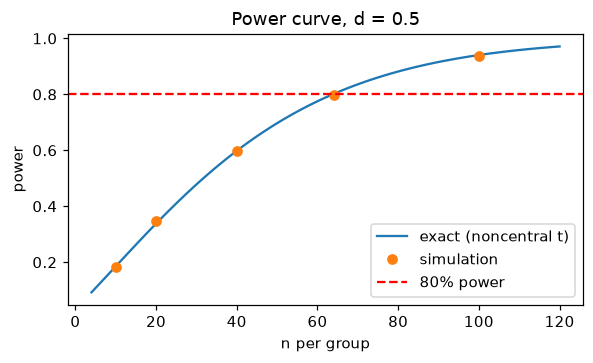

 n per group  simulated power  exact power
          10            0.183        0.185
          20            0.346        0.338
          40            0.596        0.598
          64            0.798        0.801
         100            0.938        0.940


In [9]:
rng = np.random.default_rng(3)
d = 0.5; ns = [10, 20, 40, 64, 100]
sim = []
for n in ns:
    a = rng.normal(0, 1, size=(5000, n)); b = rng.normal(d, 1, size=(5000, n))
    sim.append((stats.ttest_ind(a, b, axis=1).pvalue < 0.05).mean())
grid = np.arange(4, 121)
plt.figure(figsize=(5.5, 3.4))
plt.plot(grid, [exact_power(n, d) for n in grid], label='exact (noncentral t)')
plt.plot(ns, sim, 'o', label='simulation')
plt.axhline(0.8, color='r', ls='--', label='80% power'); plt.xlabel('n per group'); plt.ylabel('power'); plt.title('Power curve, d = 0.5'); plt.legend(); plt.tight_layout(); plt.show()
print(pd.DataFrame({'n per group': ns, 'simulated power': sim, 'exact power': [exact_power(n, d) for n in ns]}).round(3).to_string(index=False))

## Part 5 · Bootstrap confidence interval for accuracy

A single test-set accuracy is a point estimate. Resampling the test set with replacement (the **bootstrap**) shows how much it would wobble on a different test set of the same size. The result is compared with the normal-approximation (Wald) interval p̂ ± 1.96·√(p̂(1−p̂)/n).

n_test = 143, accuracy = 0.9441
Bootstrap 95% CI: [0.9021, 0.9790]
Wald 95% CI:      [0.9064, 0.9817]


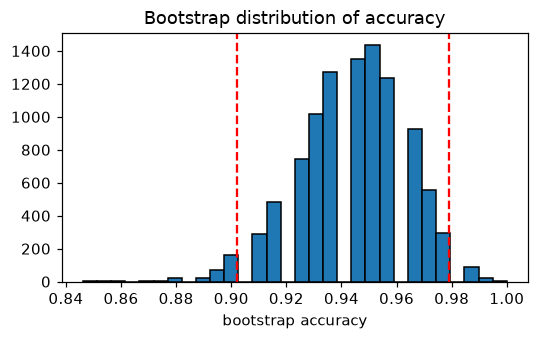

In [10]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
clf = DecisionTreeClassifier(max_depth=3, random_state=0).fit(Xtr, ytr)
correct = (clf.predict(Xte) == yte).astype(int)
n = len(correct); acc = correct.mean()
rng = np.random.default_rng(4)
boot = np.array([correct[rng.integers(0, n, n)].mean() for _ in range(10000)])
lo, hi = np.percentile(boot, [2.5, 97.5])
wald = 1.96 * np.sqrt(acc * (1 - acc) / n)
print(f"n_test = {n}, accuracy = {acc:.4f}")
print(f"Bootstrap 95% CI: [{lo:.4f}, {hi:.4f}]")
print(f"Wald 95% CI:      [{acc - wald:.4f}, {acc + wald:.4f}]")
plt.figure(figsize=(5, 3.2)); plt.hist(boot, bins=30, edgecolor='k'); plt.axvline(lo, color='r', ls='--'); plt.axvline(hi, color='r', ls='--')
plt.xlabel('bootstrap accuracy'); plt.title('Bootstrap distribution of accuracy'); plt.tight_layout(); plt.show()

## Part 6 · Checking the note's hand-worked example (paired vs Welch)

Note 01, §24 (Worked Example 2) compares two models over 5 seeds by hand. The same numbers are reproduced here so that every figure in the note is machine-checked.

In [11]:
A = np.array([0.800, 0.825, 0.809, 0.840, 0.818])   # model A, seeds 1-5
B = np.array([0.817, 0.834, 0.826, 0.854, 0.829])   # model B, same seeds / splits
d = B - A
w = stats.ttest_ind(B, A, equal_var=False)
pr = stats.ttest_rel(B, A)
print('means', A.mean().round(4), B.mean().round(4), ' SDs', A.std(ddof=1).round(4), B.std(ddof=1).round(4))
print('diffs', d.round(3), ' mean diff', d.mean().round(4), ' SD diff', d.std(ddof=1).round(5))
print(f'Welch : t = {w.statistic:.3f}, df = {w.df:.2f}, p = {w.pvalue:.4f}')
print(f'Paired: t = {pr.statistic:.3f}, df = 4, p = {pr.pvalue:.5f}')
print('corr(A, B) =', np.corrcoef(A, B)[0, 1].round(3))
se = d.std(ddof=1) / np.sqrt(5); tc = stats.t.ppf(0.975, 4)
print(f'95% CI for gain: [{d.mean() - tc*se:.4f}, {d.mean() + tc*se:.4f}]')

means 0.8184 0.832  SDs 0.0153 0.0138
diffs [0.017 0.009 0.017 0.014 0.011]  mean diff 0.0136  SD diff 0.00358
Welch : t = 1.477, df = 7.91, p = 0.1783
Paired: t = 8.500, df = 4, p = 0.00105
corr(A, B) = 0.975
95% CI for gain: [0.0092, 0.0180]


The two models move up and down together (correlation ≈ 0.975 across seeds), so the split-to-split noise is shared. Welch's test treats that shared noise as uncertainty and finds nothing (p ≈ 0.18); the paired test removes it and finds a clear gain (p ≈ 0.001). **The design (paired) decides the test.**

## Part 7 · Sample size for a target margin of error

For a proportion estimated from a simple random sample, the 95 % margin of error is E = z·√(p(1−p)/n), so n = z²p(1−p)/E². The worst case is p = 0.5. For a finite population of size N, the correction n = n₀ / (1 + (n₀ − 1)/N) applies.

 margin E  n0 (exact)  n0 (round up)  N=2000  N=10000
     0.10       96.04             97      92       96
     0.05      384.15            385     323      370
     0.04      600.23            601     462      567
     0.03     1067.07           1068     697      965
     0.02     2400.91           2401    1092     1937
     0.01     9603.65           9604    1656     4900

p = 0.2, E = 0.05 -> 245.85
mean: sigma = 12 ms, E = 2 ms, 95% -> 138.29


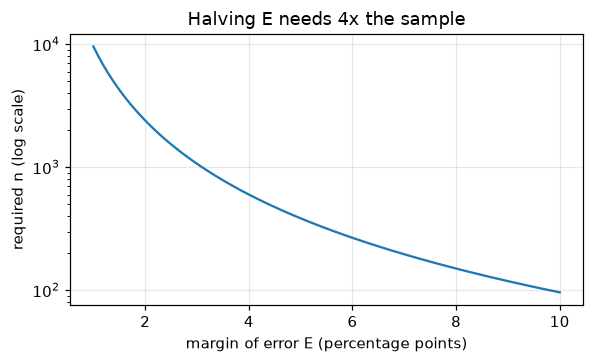

coverage of +-0.05 at n = 385 (simulated): 0.9469


In [12]:
z = stats.norm.ppf(0.975)
def n_prop(E, p=0.5, conf=0.95):
    zz = stats.norm.ppf(1 - (1 - conf) / 2)
    return zz**2 * p * (1 - p) / E**2
def fpc(n0, N):
    return n0 / (1 + (n0 - 1) / N)
rows = []
for E in [0.10, 0.05, 0.04, 0.03, 0.02, 0.01]:
    n0 = n_prop(E)
    rows.append({'margin E': E, 'n0 (exact)': round(n0, 2), 'n0 (round up)': int(np.ceil(n0)),
                 'N=2000': int(np.ceil(fpc(n0, 2000))), 'N=10000': int(np.ceil(fpc(n0, 10000)))})
print(pd.DataFrame(rows).to_string(index=False))
print()
print('p = 0.2, E = 0.05 ->', round(n_prop(0.05, 0.2), 2))
print('mean: sigma = 12 ms, E = 2 ms, 95% ->', round((z * 12 / 2)**2, 2))
Es = np.linspace(0.01, 0.10, 100)
plt.figure(figsize=(5.5, 3.4)); plt.plot(Es * 100, n_prop(Es))
plt.yscale('log'); plt.xlabel('margin of error E (percentage points)'); plt.ylabel('required n (log scale)')
plt.title('Halving E needs 4x the sample'); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
# check by simulation: with n = 385 and p = 0.5, how often is |p_hat - p| <= 0.05 ?
rng = np.random.default_rng(5)
ph = rng.binomial(385, 0.5, size=200000) / 385
print('coverage of +-0.05 at n = 385 (simulated):', (np.abs(ph - 0.5) <= 0.05).mean().round(4))

## Part 8 · Same test set, two models: z-test vs McNemar

When two classifiers are scored on **the same** test items, their errors are paired. The two-proportion z-test assumes independent samples and ignores this; **McNemar's test** uses only the discordant items (b = A right/B wrong, c = A wrong/B right):

χ² = (b − c)² / (b + c), with 1 degree of freedom (an exact binomial version also exists).

First the note's numbers, then the real LR vs tree comparison from Part 1 on one split.

In [13]:
def two_prop_z(x1, n1, x2, n2):
    p1, p2 = x1 / n1, x2 / n2; pp = (x1 + x2) / (n1 + n2)
    se = np.sqrt(pp * (1 - pp) * (1 / n1 + 1 / n2)); zz = (p2 - p1) / se
    return zz, 2 * stats.norm.sf(abs(zz))
def mcnemar(b, c):
    chi = (b - c)**2 / (b + c); chic = (abs(b - c) - 1)**2 / (b + c)
    exact = min(1.0, 2 * stats.binom.cdf(min(b, c), b + c, 0.5))
    return chi, stats.chi2.sf(chi, 1), chic, stats.chi2.sf(chic, 1), exact
print('Independent test sets, 850/1000 vs 875/1000: z = %.3f, p = %.4f' % two_prop_z(850, 1000, 875, 1000))
print('Same test set, b = 30, c = 55: chi2 = %.3f (p = %.4f), corrected %.3f (p = %.4f), exact p = %.4f' % mcnemar(30, 55))
print('Practice: b = 12, c = 28: chi2 = %.3f (p = %.4f), corrected %.3f (p = %.4f), exact p = %.4f' % mcnemar(12, 28))
print('Practice: 960/1200 vs 996/1200: z = %.3f, p = %.4f' % two_prop_z(960, 1200, 996, 1200))

Independent test sets, 850/1000 vs 875/1000: z = 1.623, p = 0.1045
Same test set, b = 30, c = 55: chi2 = 7.353 (p = 0.0067), corrected 6.776 (p = 0.0092), exact p = 0.0088
Practice: b = 12, c = 28: chi2 = 6.400 (p = 0.0114), corrected 5.625 (p = 0.0177), exact p = 0.0166
Practice: 960/1200 vs 996/1200: z = 1.892, p = 0.0584


In [14]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=7, stratify=y)
lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(Xtr, ytr)
dt = DecisionTreeClassifier(max_depth=3, random_state=7).fit(Xtr, ytr)
okA, okB = lr.predict(Xte) == yte, dt.predict(Xte) == yte
tab = pd.crosstab(pd.Series(okA, name='LR correct'), pd.Series(okB, name='tree correct'))
print(tab); b = int((okA & ~okB).sum()); c = int((~okA & okB).sum())
print(f'n = {len(yte)}, acc LR = {okA.mean():.4f}, acc tree = {okB.mean():.4f}, b = {b}, c = {c}')
print('McNemar chi2 = %.3f (p = %.4f), corrected %.3f (p = %.4f), exact p = %.4f' % mcnemar(b, c))
print('Naive z-test (wrongly treating them as independent): z = %.3f, p = %.4f' % two_prop_z(okB.sum(), len(yte), okA.sum(), len(yte)))

tree correct  False  True 
LR correct                
False             0      3
True             10    130
n = 143, acc LR = 0.9790, acc tree = 0.9301, b = 10, c = 3
McNemar chi2 = 3.769 (p = 0.0522), corrected 2.769 (p = 0.0961), exact p = 0.0923
Naive z-test (wrongly treating them as independent): z = 1.987, p = 0.0469


On this split LR is right on 10 items the tree gets wrong and wrong on 3 items the tree gets right. The naive z-test gives p ≈ 0.047 ("significant"), but McNemar, which correctly uses only the 13 discordant items, gives p ≈ 0.05 to 0.10 depending on the version. With only 13 informative items the evidence is borderline; more test data or repeated splits (Part 1) are needed before claiming a win.

## Part 9 · Confounding and Simpson's paradox

**Classic data (kidney-stone treatments, Charig et al., 1986):** treatment A is better for small stones *and* for large stones, yet B looks better overall, because doctors gave A mostly to the harder (large-stone) cases. Stone size is a **confounder**: it influences both the treatment choice and the outcome.

The same trap appears in ML when two models are evaluated on test sets with different mixes of easy and hard items.

In [15]:
kid = pd.DataFrame({'treatment': ['A', 'A', 'B', 'B'], 'stone': ['small', 'large', 'small', 'large'],
                    'success': [81, 192, 234, 55], 'n': [87, 263, 270, 80]})
kid['rate'] = (kid.success / kid.n).round(4)
print(kid.to_string(index=False))
tot = kid.groupby('treatment')[['success', 'n']].sum(); tot['rate'] = (tot.success / tot.n).round(4)
print(); print('Crude (pooled):'); print(tot)

ml = pd.DataFrame({'model': ['A', 'A', 'B', 'B'], 'subset': ['easy', 'hard', 'easy', 'hard'],
                   'correct': [450, 30, 92, 170], 'n': [500, 100, 100, 500]})
ml['acc'] = (ml.correct / ml.n).round(4)
print(); print(ml.to_string(index=False))
t2 = ml.groupby('model')[['correct', 'n']].sum(); t2['acc'] = (t2.correct / t2.n).round(4); print(t2)
# fair comparison: standardise both models to the same easy/hard mix (50/50)
std = ml.pivot(index='model', columns='subset', values='acc').mean(axis=1)
print('Accuracy standardised to a 50/50 easy/hard mix:'); print(std.round(4))

treatment stone  success   n   rate
        A small       81  87 0.9310
        A large      192 263 0.7300
        B small      234 270 0.8667
        B large       55  80 0.6875

Crude (pooled):
           success    n    rate
treatment                      
A              273  350  0.7800
B              289  350  0.8257

model subset  correct   n  acc
    A   easy      450 500 0.90
    A   hard       30 100 0.30
    B   easy       92 100 0.92
    B   hard      170 500 0.34
       correct    n     acc
model                      
A          480  600  0.8000
B          262  600  0.4367
Accuracy standardised to a 50/50 easy/hard mix:
model
A    0.60
B    0.63
dtype: float64


In [16]:
# A simulated confounder: 'GPU budget' drives both the choice of a big model and the amount of tuning,
# and tuning (not model size) raises accuracy. A naive regression credits the model.
rng = np.random.default_rng(6); n = 2000
budget = rng.normal(0, 1, n)                              # confounder
big = (budget + rng.normal(0, 1, n) > 0).astype(float)    # treatment depends on confounder
acc = 0.80 + 0.00 * big + 0.03 * budget + rng.normal(0, 0.01, n)   # true model effect = 0
naive = np.polyfit(big, acc, 1)[0]
Xd = np.column_stack([np.ones(n), big, budget]); beta = np.linalg.lstsq(Xd, acc, rcond=None)[0]
print(f'naive effect of big model = {naive:.4f}  (spurious)')
print(f'adjusted for budget       = {beta[1]:.4f}  (true effect is 0)')

naive effect of big model = 0.0358  (spurious)
adjusted for budget       = 0.0001  (true effect is 0)


## Part 10 · p-hacking by optional stopping

A researcher runs a comparison with 5 seeds, checks p, and if p ≥ 0.05 adds 5 more seeds and checks again, up to 50 seeds, stopping as soon as p < 0.05. Even when **H₀ is true**, this "peeking" pushes the false-positive rate far above 5 %.

In [17]:
rng = np.random.default_rng(8)
reps, looks = 4000, list(range(5, 51, 5))
fp_fixed, fp_peek = 0, 0
for _ in range(reps):
    a = rng.normal(0.85, 0.01, 50); b = rng.normal(0.85, 0.01, 50)   # identical models
    fp_fixed += stats.ttest_ind(a, b).pvalue < 0.05                  # one test at n = 50
    fp_peek += any(stats.ttest_ind(a[:k], b[:k]).pvalue < 0.05 for k in looks)
print(f'Fixed n = 50, single test : false-positive rate = {fp_fixed / reps:.4f}')
print(f'Peek every 5 seeds (10 looks): false-positive rate = {fp_peek / reps:.4f}')

Fixed n = 50, single test : false-positive rate = 0.0522
Peek every 5 seeds (10 looks): false-positive rate = 0.2023


## Part 11 · Positive predictive value of a "significant" finding

Ioannidis (2005): if R is the prior odds that a tested hypothesis is true, the share of significant results that are true is

PPV = (1 − β)·R / ((1 − β)·R + α).

Low power and long-shot hypotheses make most "discoveries" false, which is one mechanism behind the reproducibility crisis.

In [18]:
def ppv(R, power, alpha=0.05):
    return power * R / (power * R + alpha)
grid = pd.DataFrame([{'prior odds R': R, 'power': pw, 'PPV': round(ppv(R, pw), 4)}
                     for R in [1, 0.5, 0.25, 0.1] for pw in [0.8, 0.5, 0.2]])
print(grid.pivot(index='prior odds R', columns='power', values='PPV'))

power            0.2     0.5     0.8
prior odds R                        
0.10          0.2857  0.5000  0.6154
0.25          0.5000  0.7143  0.8000
0.50          0.6667  0.8333  0.8889
1.00          0.8000  0.9091  0.9412


## Takeaways

1. Run every ML comparison over **several seeds** and report mean ± spread; prefer a **paired** analysis when both models share splits.
2. A p-value depends on both effect size and n; always report **effect size + confidence interval**.
3. At α = 0.05, about 1 in 20 true-null comparisons is "significant"; running many comparisons without correction almost guarantees a false discovery.
4. Decide the number of runs **before** the experiment with a power analysis.
5. A test accuracy measured on ~140 samples carries an uncertainty of several percentage points; differences smaller than that are not evidence.
6. **Pairing matters:** the same 5-seed data give p ≈ 0.18 (Welch) or p ≈ 0.001 (paired). Choose the test that matches the design.
7. Required sample size grows as 1/E²: halving the margin of error needs four times the data.
8. Two models on one test set → **McNemar**, not a two-proportion z-test.
9. Always ask what else differs between the groups: a confounder can reverse a conclusion (Simpson's paradox).
10. Fix n in advance (or use a sequential design); peeking until p < 0.05 inflates false positives several-fold.
11. Low power + unlikely hypotheses ⇒ many published 'discoveries' are false; pre-registration and replication are the cure.